## 3. Modelo de Clasificación
### 3.1 Tratamiento de Datos y Discretización
* **Valores CONFIDENCIAL / SIN DATO:**
 Se detectaron que habia registros con un status CONFIDENCIAL que se asimilan a la decision que se tomo en la tarea pasada.Para la preparacion de datos necesitamos eliminarlos para asi contar con casos que podamos tener certeza
* **Discretización:** Para el rango de edad se prefirio tenerlos como un `grupo de edad` donde tendremos menor, adulto y adulto mayor por lo cual ayuda a reducir el sesgo demografico
* **Ingeniería de Características:** Estuvimos checando diferentes columnas por ejemplo `MUNICIPIO` pero nos percatamos que se generarian muchisimas columnas unicamente indicando la localidad por lo cual se optp por tener `ENTIDAD`. Agregamos `Estacionalidad`(dia de la semana y mes) dado que se podria tener mas reportes que se clasifiquen como "No localizada" por el hecho que se podria ir de fiesta en un fin de semana.Por ultimo se creó la variable `DIAS_RETRASO_REPORTE` (diferencia entre fecha de desaparición y registro) para evaluar si el tiempo de reacción administrativa.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

df = pd.read_csv('data_secretariado.csv')
df_ml = df[df['ESTATUS_VICTIMA'] != 'CONFIDENCIAL'].copy()

# Manejamos las Fechas
cols_fechas = ['FECHA_NACIMIENTO', 'FECHA_DESAPARICION', 'FECHA_REGISTRO']
for col in cols_fechas:
    df_ml[col] = pd.to_datetime(df_ml[col], errors='coerce')

# Estacionalidad y tiempos
df_ml['DIAS_RETRASO'] = (df_ml['FECHA_REGISTRO'] - df_ml['FECHA_DESAPARICION']).dt.days
df_ml.loc[df_ml['DIAS_RETRASO'] < 0, 'DIAS_RETRASO'] = 0
df_ml['DIAS_RETRASO'] = df_ml['DIAS_RETRASO'].fillna(0)

# Patrones de fin de semana y mes
df_ml['DIA_SEMANA'] = df_ml['FECHA_DESAPARICION'].dt.dayofweek # 0=Lunes, 6=Domingo
df_ml['ES_FIN_SEMANA'] = df_ml['DIA_SEMANA'].apply(lambda x: 1 if x >= 5 else 0)
df_ml['MES_DESAPARICION'] = df_ml['FECHA_DESAPARICION'].dt.month
df_ml['MES_DESAPARICION'] = df_ml['MES_DESAPARICION'].fillna(0)

# Calculo y Discretización de Edad
df_ml['EDAD'] = df_ml['FECHA_DESAPARICION'].dt.year - df_ml['FECHA_NACIMIENTO'].dt.year
df_ml.loc[(df_ml['EDAD'] < 0) | (df_ml['EDAD'] > 120), 'EDAD'] = np.nan
df_ml['EDAD'] = df_ml['EDAD'].fillna(df_ml['EDAD'].median())

bins = [0, 17, 59, 120]
labels = ['MENOR (0-17)', 'ADULTO (18-59)', 'ADULTO MAYOR (60+)']
df_ml['GRUPO_EDAD'] = pd.cut(df_ml['EDAD'], bins=bins, labels=labels, include_lowest=True)

# Preparación de variables predictoras 
features = ['SEXO', 'ENTIDAD', 'GRUPO_EDAD', 'DIAS_RETRASO', 'ES_FIN_SEMANA', 'MES_DESAPARICION']
X = pd.get_dummies(df_ml[features], drop_first=True)
y = df_ml['ESTATUS_VICTIMA'].map({'NO LOCALIZADA': 0, 'DESAPARECIDA': 1})

# Train/Test con Estratificación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Set de Entrenamiento listo: {X_train.shape[0]} registros.")
print(f"Set de Prueba listo: {X_test.shape[0]} registros.")

Set de Entrenamiento listo: 67790 registros.
Set de Prueba listo: 16948 registros.


### 3.2 Justificación de Métricas de Evaluación
El dataset presenta un fuerte desbalance de clases (la inmensa mayoría de los registros corresponden a "Desaparecida" y una minoría a "No Localizada"). Si utilizáramos únicamente el **Accuracy (Exactitud)**, el modelo podría alcanzar un 95% simplemente prediciendo que todos están desaparecidos, lo cual es inútil.
Por lo tanto, seleccionamos las siguientes métricas:
1. **Recall (Sensibilidad) de la clase minoritaria y prioritaria:** Dado que laspersonas desaparecidas, es el indicador más crítico. Si hay un "Falso Negativo" retrasa protocolos de búsqueda urgente y pone en riesgo la vida de la persona. Priorizamos que el modelo minimice este error.
2. **F1-Score:** Nos ayuda a encontrar el equilibrio armónico entre Precision y Recall frente al fuerte desbalance.
   Para minorizar los errores en la clase minoritaria nos basamos con class_weight= 'balanced' 

--- MÉTRICAS DE DESEMPEÑO PRINCIPALES ---
Accuracy (Exactitud) : 0.8252
Recall General       : 0.8345 
F1-Score             : 0.9000

--- REPORTE DETALLADO POR CLASE ---
                   precision    recall  f1-score   support

NO LOCALIZADA (0)       0.20      0.67      0.31       971
 DESAPARECIDA (1)       0.98      0.83      0.90     15977

         accuracy                           0.83     16948
        macro avg       0.59      0.75      0.60     16948
     weighted avg       0.93      0.83      0.87     16948



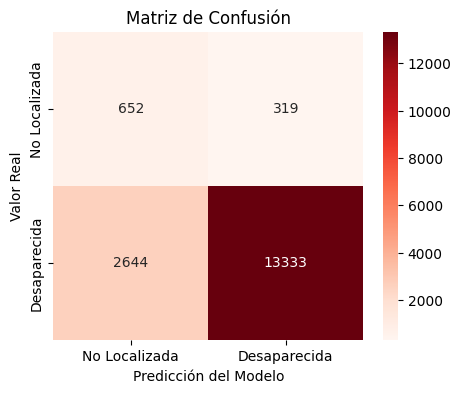

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamos al modelo (Random Forest con balanceo de pesos)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', max_depth=12)
modelo_rf.fit(X_train, y_train)

# Predecimos con el set de prueba
y_pred = modelo_rf.predict(X_test)

# Reporte
print("--- MÉTRICAS DE DESEMPEÑO PRINCIPALES ---")
print(f"Accuracy (Exactitud) : {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall General       : {recall_score(y_test, y_pred):.4f} ")
print(f"F1-Score             : {f1_score(y_test, y_pred):.4f}\n")

print("--- REPORTE DETALLADO POR CLASE ---")
print(classification_report(y_test, y_pred, target_names=['NO LOCALIZADA (0)', 'DESAPARECIDA (1)']))

# Matriz de Confusión Visual
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No Localizada', 'Desaparecida'], 
            yticklabels=['No Localizada', 'Desaparecida'])
plt.title('Matriz de Confusión')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()

Al evaluar el rendimiento del clasificador Random Forest, más allá de la métrica de Accuracy (82.52%), la matriz de confusión revela el verdadero comportamiento del sistema y cómo maneja los diferentes tipos de errores. A continuación, se presenta el desglose de los cuadrantes sobre el conjunto de prueba (16,948 registros):

**Verdaderos Positivos (13,333 casos):** El modelo logró clasificar correctamente a la gran mayoría de las personas que, según los registros, efectivamente son víctimas con estatus de "Desaparecida".

**Verdaderos Negativos (652 casos):** El algoritmo identificó acertadamente a las personas que solo presentaban una ausencia y fueron catalogadas como "No Localizadas".

**Falsos Positivos (319 casos):** El modelo predijo que estas personas estaban "Desaparecidas" cuando el registro real era "No Localizadas". En el contexto del mundo real (búsqueda de personas), este es un error tolerable e incluso preferible. Significa que el sistema asume un nivel de riesgo mayor, lo cual desencadenaría protocolos de búsqueda temprana en lugar de minimizar el riesgo.

**Falsos Negativos (2,644 casos):** Este es el punto crítico del análisis. El modelo clasificó erróneamente a más de 2,600 personas bajo el estatus administrativo de "No Localizadas" cuando en realidad sí eran víctimas de desaparición.

/tmp/ipykernel_10254/2797822420.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='magma')


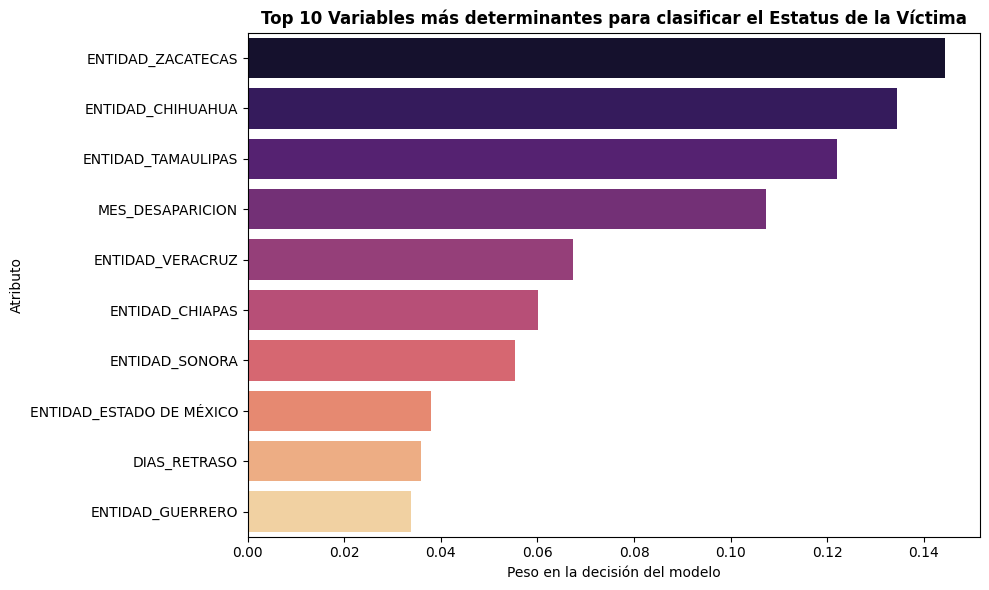

In [3]:
# Extraemos la importancia matemática de las variables según el árbol de decisión
importancias = modelo_rf.feature_importances_
nombres_columnas = X_train.columns

df_importancia = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias})
# Tomamos las 10 entidades más importantes
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

# Grafica
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='magma')
plt.title('Top 10 Variables más determinantes para clasificar el Estatus de la Víctima', fontweight='bold', fontsize=12)
plt.xlabel('Peso en la decisión del modelo')
plt.ylabel('Atributo')
plt.tight_layout()
plt.show()

Al extraer la importancia que el algoritmo Random Forest le dio a cada variable (`Feature Importance`), los resultados numéricos revelan una falla sistémica en la clasificación nacional:

1. **La Irrelevancia Demográfica:** Contrario a lo que se esperaría en un análisis de víctimas, las características inherentes a la vulnerabilidad de la persona (como la `EDAD` o el `SEXO`) **fueron expulsadas por completo del Top 10**. Para el sistema que asigna las clasificaciones legales, la identidad de la víctima es estadísticamente irrelevante.
2. **El Dominio Geográfico Absoluto:** El estatus legal depende primordialmente de dónde desaparece la persona. El Top 3 de variables determinantes está ocupado exclusivamente por entidades: **Zacatecas (14%)**, **Chihuahua (~13%)** y **Tamaulipas (~12%)**. Esto demuestra que las fiscalías de estados con fuertes crisis de seguridad aplican criterios radicalmente distintos al resto del país, saltándose protocolos y evidenciando la falta de un criterio federal homologado.
3. **Estacionalidad sobre Tiempo de Respuesta:** Sorprendentemente, el **Mes de Desaparición (~10%)** tiene un peso mucho mayor que el tiempo que la familia tarda en denunciar (**Días de Retraso**, relegado al 9° lugar con apenas **3.7%**). El algoritmo detectó un fuerte patrón temporal o "estacional" en la forma en que las autoridades clasifican los casos.